In [1]:
!pip install networkx

In [20]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from scipy.optimize import curve_fit
from fonctions import constitution_df, construction_reseau, degree_distribution

A faire : ajouter une intro avec titre + rappel bref de l'objectif du projet
+ préciser le champ de l'étude (NYC?)

# 1.Téléchargement des données et constitution des dataframes

In [3]:
path_data_check_in='/home/onyxia/work/Networks_projet/data/dataset_TSMC2014_TKY.txt'
path_data_users='/home/onyxia/work/Networks_projet/data/dataset_UbiComp2016_UserProfile_TKY.txt'

dfjoint_complet, dfjoint_micro, dfjoint_macro=constitution_df(path_data_check_in,path_data_users )


In [4]:
# Distribution du nombre de followers parmi les users

dfjoint_complet['nb_twitter_followers'].quantile(
    [i/10 for i in range(1, 10)]
)

0.1     120.5
0.2     217.0
0.3     326.0
0.4     473.0
0.5     661.5
0.6     873.0
0.7    1084.0
0.8    1427.0
0.9    2360.0
Name: nb_twitter_followers, dtype: float64

# 2. Etude des réseaux

Nous commencerons par constituer un réseau complet tel que:
- les noeuds sont constitués d'établissements visités plus d'une fois
- ces établissements sont connectés par une arête si ils ont été visités par au moins un utilisateur commun

Puis nous focaliserons notre étude sur deux sous-réseaux:
- un réseau dont les liens ne sont constitués que par des utilisateurs ayant moins de 100 followers
- un réseau dont les liens sont constitués par des utilisateurs ayant plus de 2500 followers

Les seuils ont été déterminés en tenant compte de leur intreprétabilité la distribution de la variable *nb_twitter_followers*.

## 2.1 Constitution des réseaux


In [5]:
# Création du réseau

G_complet= construction_reseau(dfjoint_complet)
G_micro= construction_reseau(dfjoint_micro)
G_macro= construction_reseau(dfjoint_macro)

In [ ]:
# Création du réseau

# A partir de la liste de la colonne checkins: liste de toutes les combinaisons possibles de deux lieux visités par un utilisateur commun
dfjoint_micro['edges']=dfjoint_micro['checkins'].apply(lambda x: list(itertools.combinations(x,2)))

def flatten(l):
    return [item for sublist in l for item in sublist]

edges=flatten(dfjoint_micro['edges'].tolist())

# Création du réseau à partir de la liste d'arêtes edges
G=nx.Graph()
G.add_edges_from(edges)

# Suppression des self-loops
G.remove_edges_from(nx.selfloop_edges(G))

In [6]:
def afficher_infos_reseau(G, titre):
    print("\n" + "="*50)
    print(f"{titre}")
    print("="*50)
    print(f"Nombre de lieux (nœuds) : {G.number_of_nodes()}")
    print(f"Nombre de connexions (arêtes) : {G.number_of_edges()}")
    print(f"Densité du réseau : {nx.density(G):.4f}")
    print(f"Réseau entièrement connecté : {nx.is_connected(G)}")


# Affichages
afficher_infos_reseau(G_complet, "RÉSEAU COMPLET")
afficher_infos_reseau(G_macro, "RÉSEAU MACRO")
afficher_infos_reseau(G_micro, "RÉSEAU MICRO")


RÉSEAU COMPLET
Nombre de lieux (nœuds) : 61858
Nombre de connexions (arêtes) : 10865915
Densité du réseau : 0.0057
Réseau entièrement connecté : True

RÉSEAU MACRO
Nombre de lieux (nœuds) : 3836
Nombre de connexions (arêtes) : 257049
Densité du réseau : 0.0349
Réseau entièrement connecté : True

RÉSEAU MICRO
Nombre de lieux (nœuds) : 2438
Nombre de connexions (arêtes) : 143991
Densité du réseau : 0.0485
Réseau entièrement connecté : True


Le réseau d'établissements est très peu dense dans les trois cas, avec, par exemple, uniquement 0,64% des arêtes possibles dans le réseau complet effectivement présentes. Ce résultat était-il prévisible? Compte tenu du nombre important de lieux répertoriés ainsi que des contraintes géographiques et des caractéristiques des comportements humains (tendance à visiter les lieux proches ou recommandés). Nous pouvons faire l'hypothèse que le réseau est structuré en différents îlots, reliés entre eux par quelques hubs servant de ponts, liaisons qui expliquent que le réseau reste entièrement connecté.

## 2.2 Distribution des degrés

In [19]:

import importlib
import fonctions  # ton fichier .py

importlib.reload(fonctions)

<module 'fonctions' from '/home/onyxia/work/Networks_projet/fonctions.py'>

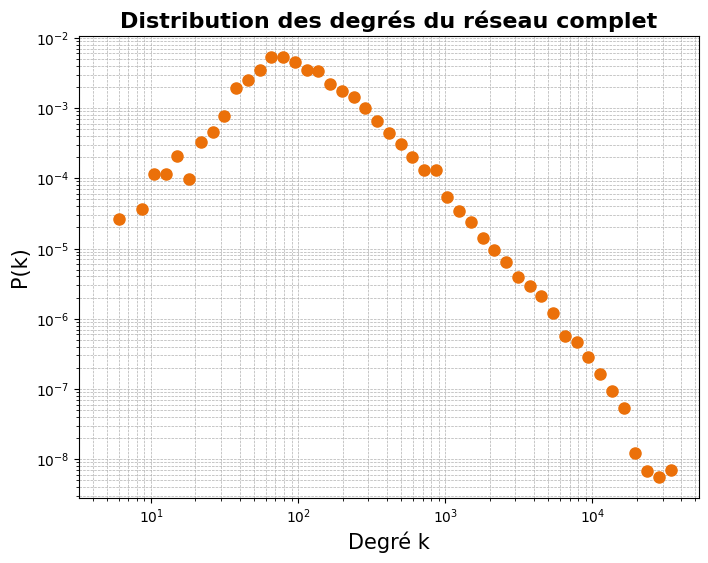

In [21]:
#  Réseau complet : distribution des degrés

degree_distribution(G_complet, titre='Distribution des degrés du réseau complet')

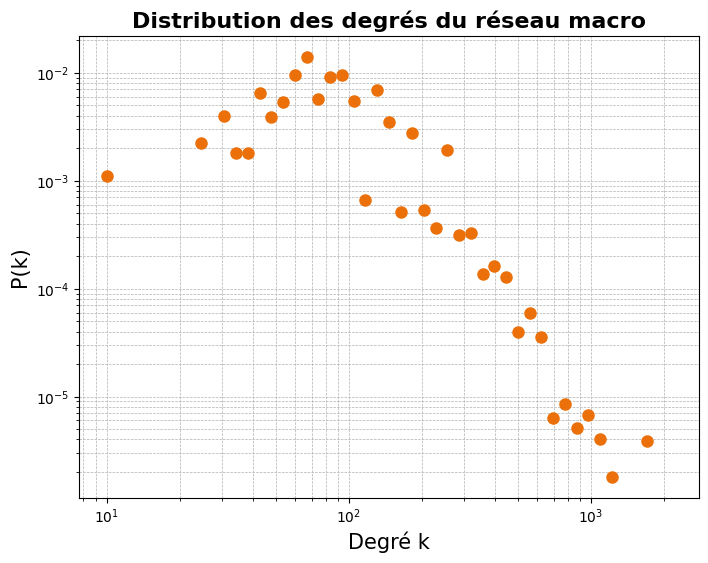

In [25]:
#  Réseau macro : distribution des degrés

degree_distribution(G_macro, titre='Distribution des degrés du réseau macro')

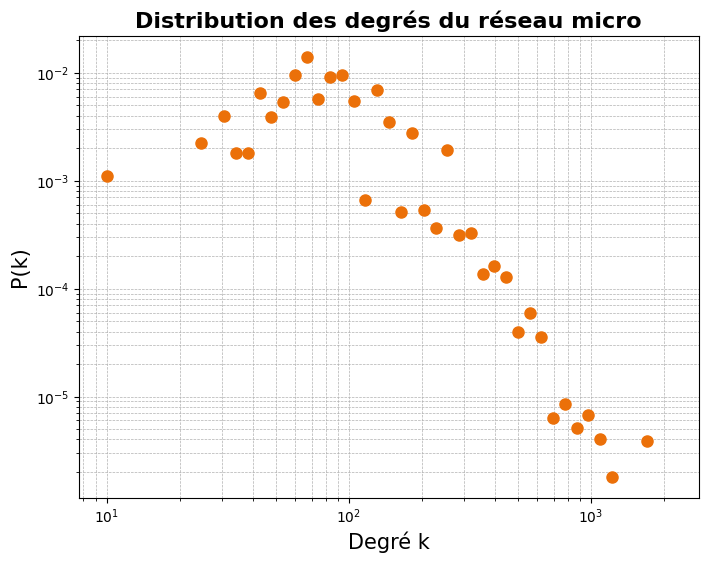

In [24]:
#  Réseau micro : distribution des degrés

degree_distribution(G_macro, titre='Distribution des degrés du réseau micro')

La loi puissance ne semble vérifiée que pour k>100 (hyp: présence de gros hubs mais peu de lieux avec très peu de connections?)
Question: est-ce que cela vaut la peine de creuser ou l'étude du micro-réseau et du macro-réseau compléteront-elles directement ce premier graphique (présence ou non d'une loi puissance dans l'un ou l'autre de ces sous-réseaux)

### Degree mixing
Objectif: répondre à la question qui se connecte avec qui?

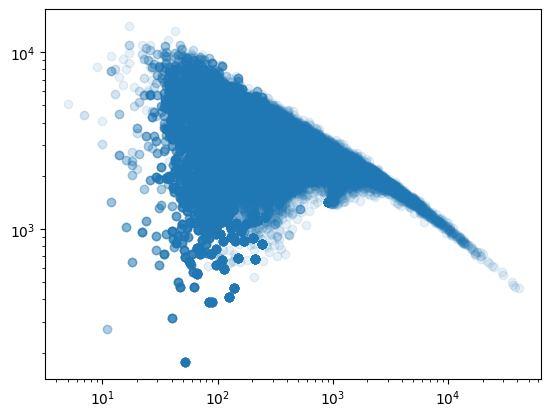

In [51]:
# Calcul du degré moyen de ses voisins pour chaque noeud
knn={}
for n in G.nodes():
    neighbors_degrees=[kDict[v] for v in G.neighbors(n)]
    knn[n]=np.mean(neighbors_degrees)


# Tracé de (k, neighbors_degrees_mean )
xx=[]
yy=[]
for n in knn.keys():
    xx.append(kDict[n])
    yy.append(knn[n])

plt.loglog(xx,yy,'o',alpha=0.1)

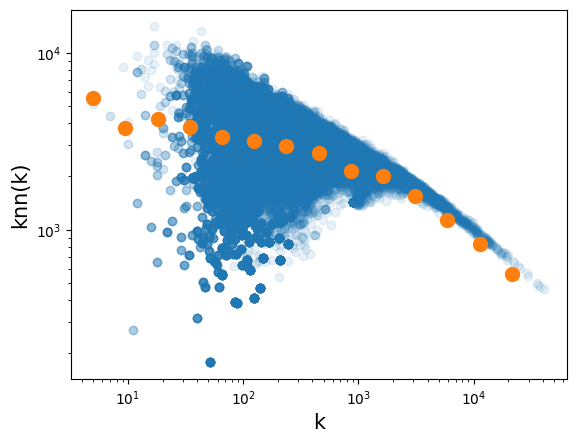

In [52]:
#  Nous regroupons les données dans des log-bins et nous traçons la moyenne de $knn$ pour chaque log-bin. 
xx=[]
yy=[]
for n in knn.keys():
    xx.append(kDict[n])
    yy.append(knn[n])

plt.loglog(xx,yy,'o',alpha=0.1)
logBins=np.logspace(np.log2(np.min(xx)),np.log2(np.max(xx)),base=2,num=15)
#if I use np.linspace I will have linear bins
ybin,xbin,binnumber=scipy.stats.binned_statistic(xx,yy,statistic='mean',bins=logBins)
plt.loglog(xbin[:-1],ybin,'o',markersize=10)

plt.xlabel('k',size=15)
plt.ylabel('knn(k)',size=15)
plt.show()

Il semblerait que tous les établissements soient connectés à des hubs.

### La propriété rich-club

La courbe est croissante sur la partie droite : plus un lieu est populaire, plus il a de chances d'être connecté à un autre lieu populaire (n'est-ce pas un simple effet mathématique du à l'augmentation du nombre de connexions?) Les lieux peu connectés semblent isolés, ce qui pourrait indiquer avec le graphique précédent qu'ils sont connectés à des hubs mais ne se connectent pas entre eux. A partir d'un certain seuil de popularité tous les lieux semblent connectés entre eux.

Pour s'assurer que l'hyperconnectivité des lieux les plus connectés n'est pas du à un simple effet mathématique, il faudrait comparer cette courbe à un réseau aléatoire.



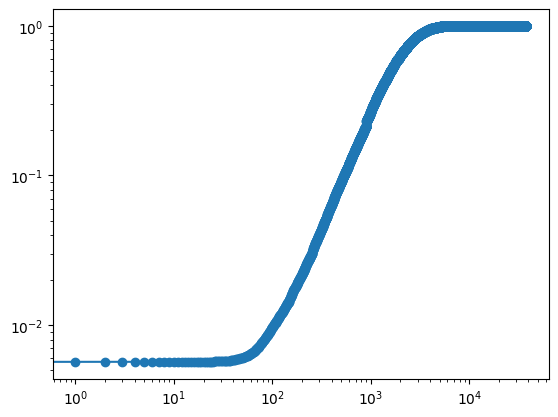

In [53]:
rc = nx.rich_club_coefficient(G, normalized=False, seed=42)
plt.loglog(rc.keys(),rc.values(),'o-')

Comparaison avec un réseau aléatoire

L'IA conseillait de créer un réseau random avec nswap (en commentaire), j'ai préféré un réseau BA comme vu en cours qui crée naturellement des hubs. Le choix est dicutable comme nous n'avons pas de loi puissance, mais c'est une façon de se fixer les idées en première approche avec une interprétation simple du réseau random créé.

On observe une synergie entre les lieux qui ont entre 100 et 200 connections notamment : les utilisateurs ont tendance à naviguer entre ces lieux. La courbe redescend ensuite (et passe même en-dessous de la ligne représentant le modèle random(modèle BA dans ce cas)) : interprétation possible : les super_hubs sont connectés avec tout le monde.

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_19883/2730399516.py:31: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi_{real} / \phi_{rand}$')


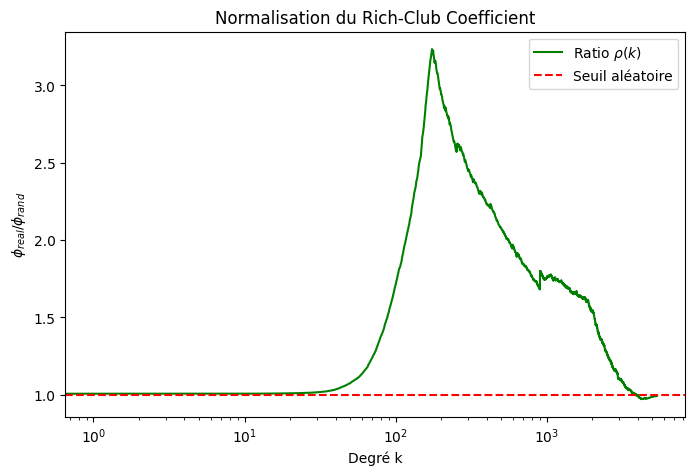

In [55]:


#  Création une version aléatoire de votre graphe G
# nswap définit le nombre de mélanges (plus il est haut, plus c'est aléatoire)
#G_random = nx.random_reference(G, nswap=G.number_of_edges() * 2, seed=42)

# Calculer le rich-club pour les deux
rc_real = nx.rich_club_coefficient(G, normalized=False)
#rc_rand = nx.rich_club_coefficient(G_random, normalized=False)

# N : nombre de nœuds de votre graphe réel
# m : nombre d'arêtes à attacher pour chaque nouveau nœud
# (On estime m par : nombre_total_aretes / nombre_total_noeuds)
N = G.number_of_nodes()
m = int(G.number_of_edges() / N)

G_ba = nx.barabasi_albert_graph(N, m)

# Calcul du rich-club pour comparer
rc_ba = nx.rich_club_coefficient(G_ba, normalized=False)

# Calculer le ratio de normalisation (rho)
# On s'assure de ne comparer que les degrés présents dans les deux
common_k = sorted(set(rc_real.keys()) & set(rc_ba.keys()))
rho = [rc_real[k] / rc_ba[k] for k in common_k]

#  Tracer le résultat
plt.figure(figsize=(8, 5))
plt.plot(common_k, rho, 'g-', label="Ratio $\\rho(k)$")
plt.axhline(y=1, color='r', linestyle='--', label="Seuil aléatoire")
plt.xscale('log')
plt.xlabel('Degré k')
plt.ylabel('$\phi_{real} / \phi_{rand}$')
plt.title('Normalisation du Rich-Club Coefficient')
plt.legend()
plt.show()